<a href="https://colab.research.google.com/github/karanveer-sharma/cdac_project/blob/master/heartcsv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
%matplotlib inline


In [ ]:
data = pd.read_csv("/content/heart - heart.csv")

In [ ]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [ ]:
data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [ ]:
data.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


<Figure size 640x480 with 0 Axes>

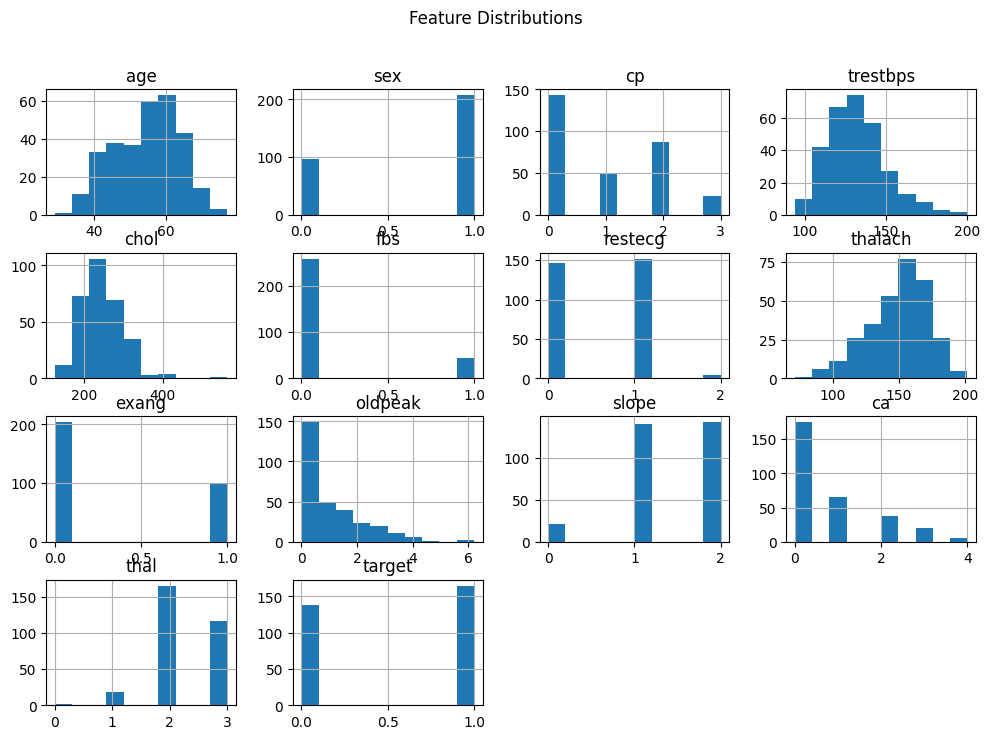

In [ ]:
plt.figure()
data.hist(figsize=(12,8))
plt.suptitle("Feature Distributions")
plt.show()

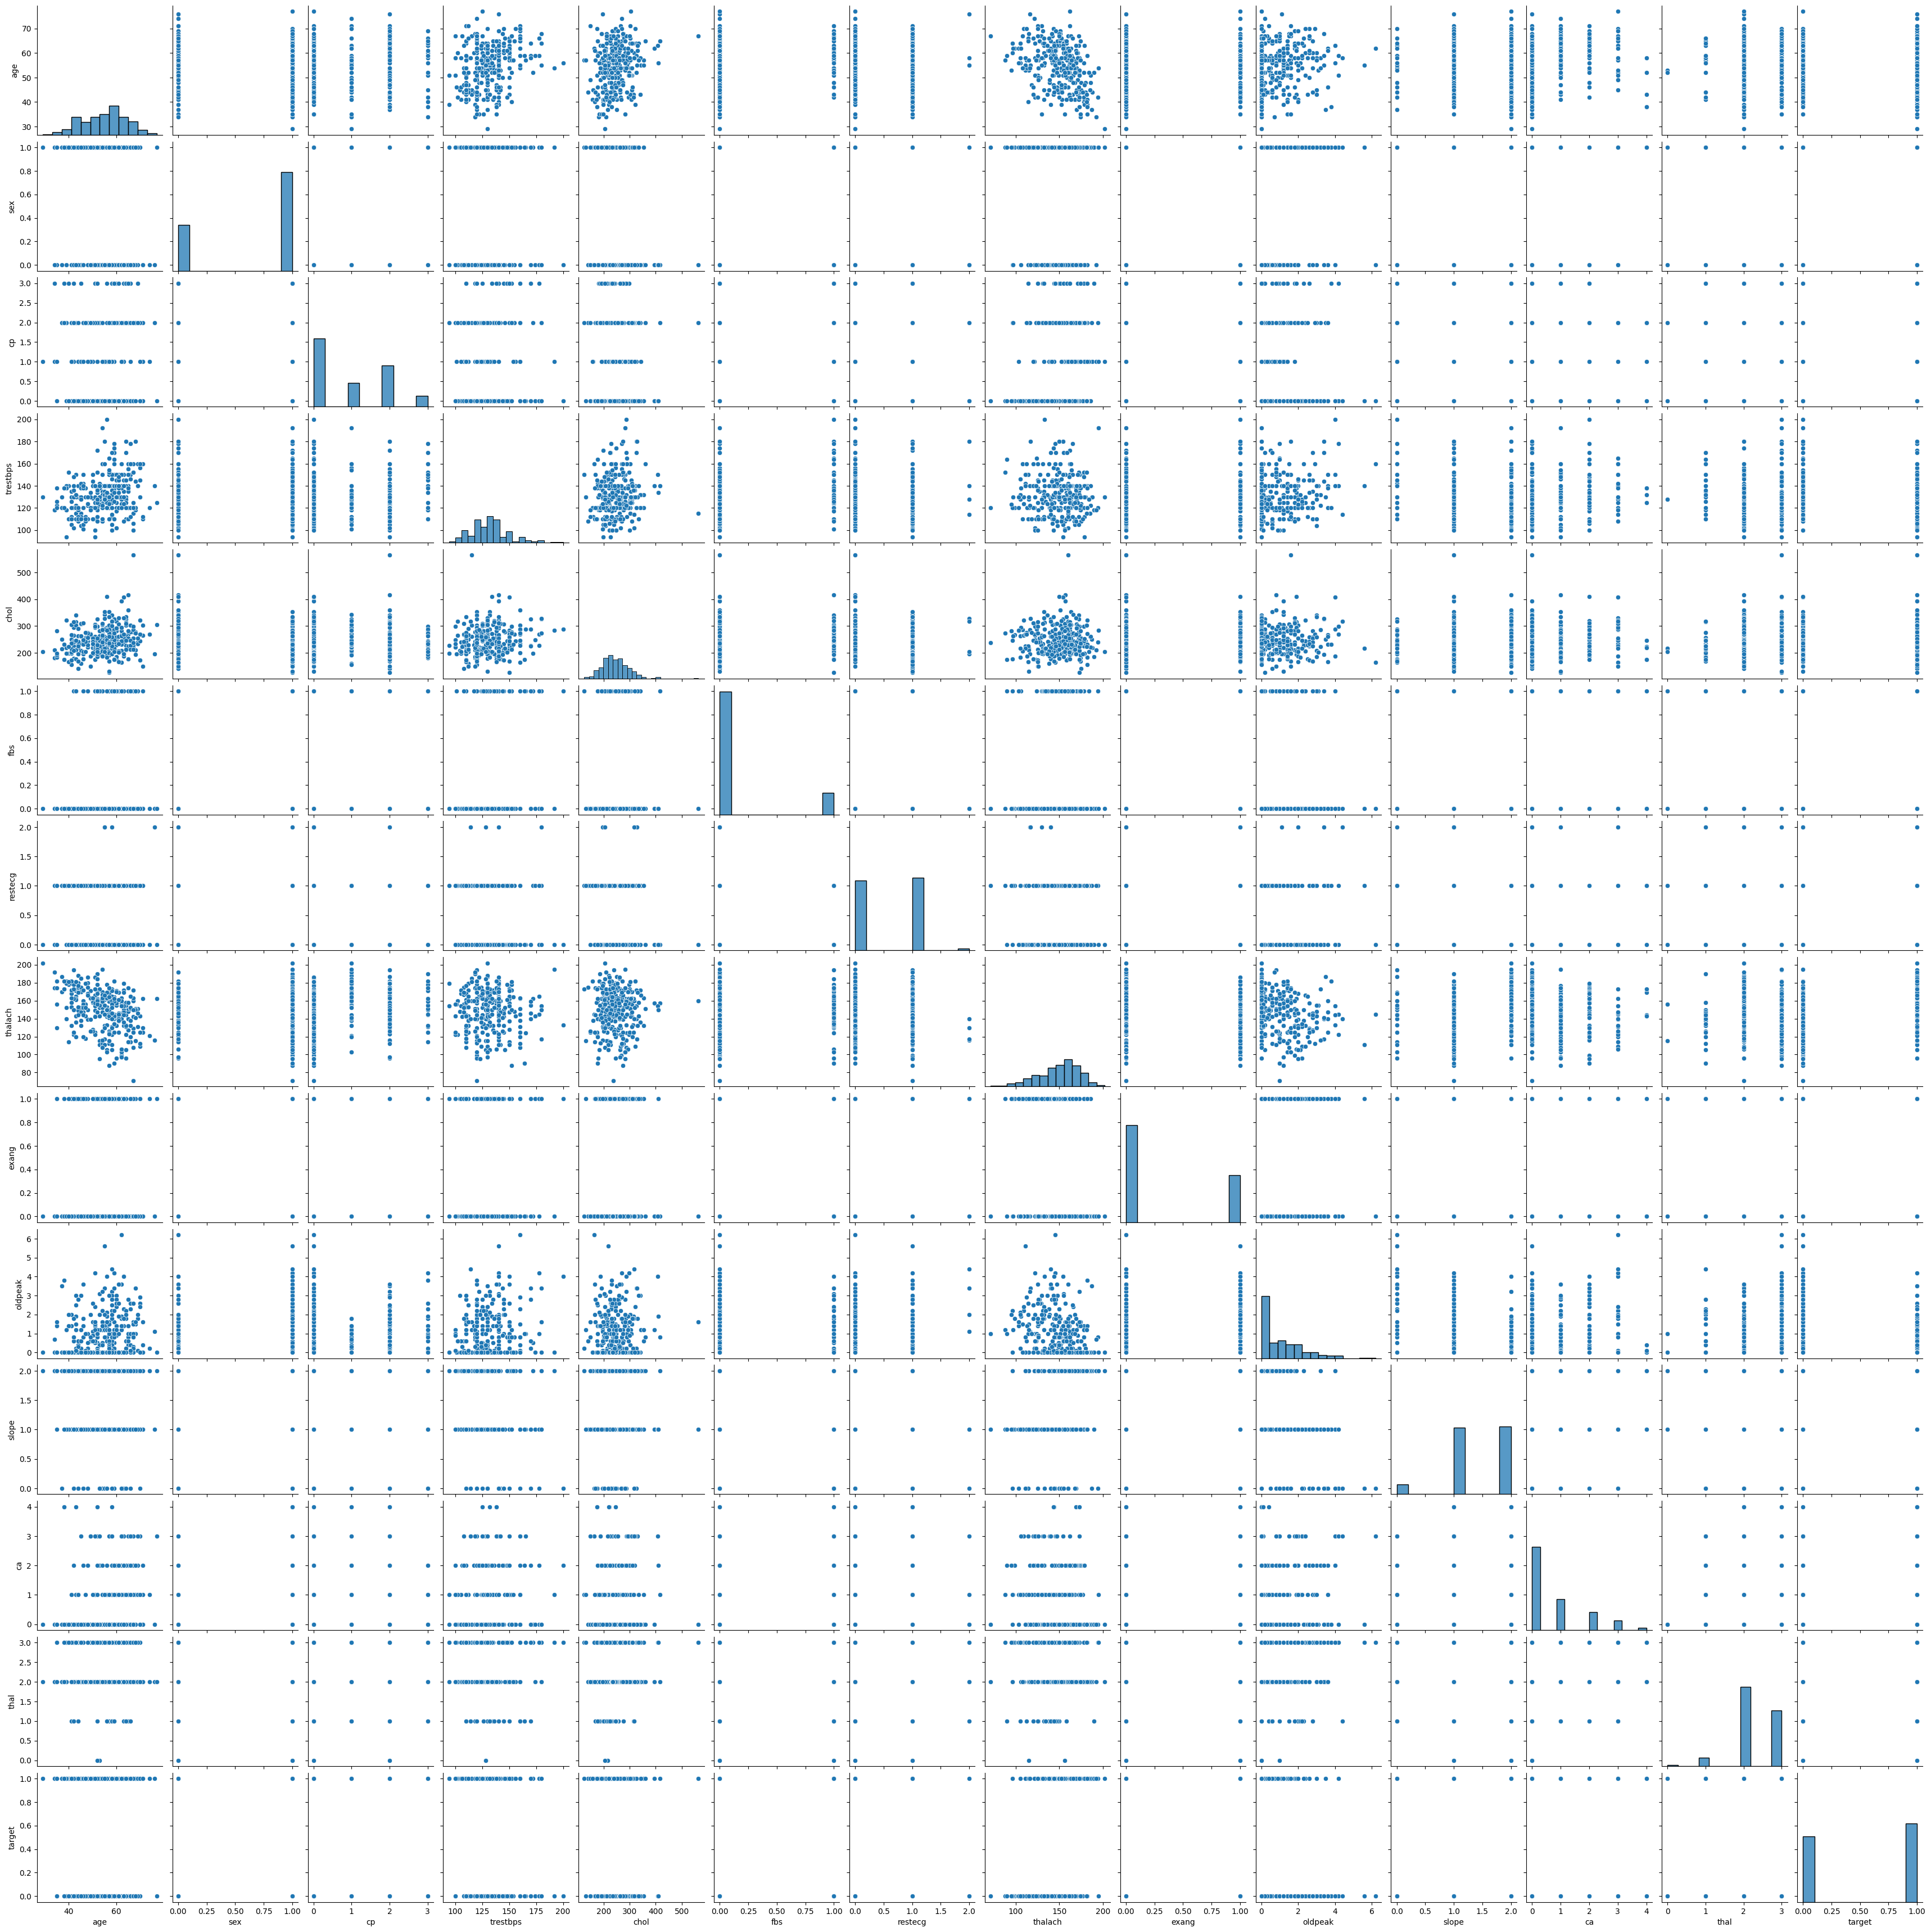

In [ ]:
sns.pairplot(data=data)

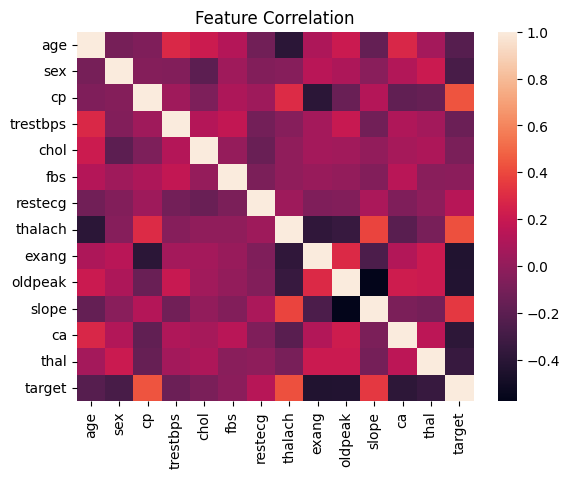

In [ ]:
plt.figure()
sns.heatmap(data.corr(), annot=False)
plt.title("Feature Correlation")
plt.show()

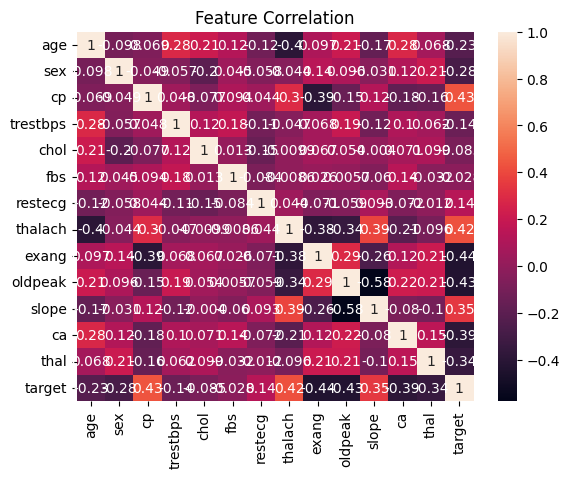

In [ ]:
plt.figure()
sns.heatmap(data.corr(), annot=True)
plt.title("Feature Correlation")
plt.show()

In [ ]:
data.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [ ]:
df_norm= data[["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalach", "exang", "oldpeak", "slope", "ca", "thal"]].apply(lambda x: (x-np.min(x))/(np.max(x)-np.min(x)))
df_norm.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,0.708333,1.0,1.000000,0.481132,0.244292,1.0,0.0,0.603053,0.0,0.370968,0.0,0.0,0.333333
1,0.166667,1.0,0.666667,0.339623,0.283105,0.0,0.5,0.885496,0.0,0.564516,0.0,0.0,0.666667
2,0.250000,0.0,0.333333,0.339623,0.178082,0.0,0.0,0.770992,0.0,0.225806,1.0,0.0,0.666667
3,0.562500,1.0,0.333333,0.245283,0.251142,0.0,0.5,0.816794,0.0,0.129032,1.0,0.0,0.666667
4,0.583333,0.0,0.000000,0.245283,0.520548,0.0,0.5,0.702290,1.0,0.096774,1.0,0.0,0.666667


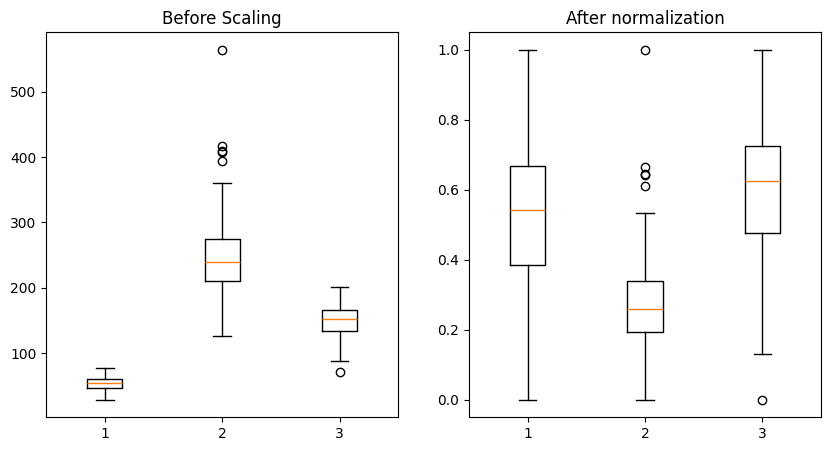

In [ ]:
fig, ax= plt.subplots(1,2, figsize=(10,5))
ax[0].boxplot(data[["age", "chol", "thalach"]].values)
ax[0].set_title("Before Scaling")
ax[1].boxplot(df_norm[["age", "chol", "thalach"]].values)
ax[1].set_title("After normalization")
plt.show()

In [ ]:
target= data["target"]
target.head()

,target
0,1
1,1
2,1
3,1
4,1


In [ ]:
data= pd.concat([df_norm, target], axis=1)
data.sample(n=5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
219,0.395833,1.0,0.000000,0.339623,0.296804,1.0,0.0,0.603053,1.0,0.000000,1.0,0.5,1.000000,0
164,0.187500,1.0,0.666667,0.415094,0.111872,0.0,0.5,0.778626,0.0,0.000000,1.0,1.0,0.666667,1
31,0.750000,1.0,0.000000,0.245283,0.116438,0.0,0.5,0.526718,0.0,0.064516,1.0,0.0,1.000000,1
29,0.500000,1.0,0.666667,0.339623,0.162100,1.0,0.0,0.618321,0.0,0.193548,0.0,0.0,0.666667,1
212,0.208333,1.0,0.000000,0.226415,0.212329,0.0,0.5,0.526718,0.0,0.193548,0.5,0.0,1.000000,0


In [ ]:
train_test_per=75/100.0
data["train"]= np.random.rand(len(data)) < train_test_per
data.sample(n=5)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,train
265,0.770833,1.0,0.000000,0.169811,0.196347,0.0,0.0,0.465649,1.0,0.016129,1.0,0.25,0.666667,0,False
106,0.833333,1.0,1.000000,0.622642,0.246575,1.0,0.0,0.458015,0.0,0.016129,0.5,0.25,0.666667,1,True
201,0.645833,1.0,0.000000,0.292453,0.301370,0.0,0.0,0.534351,1.0,0.451613,0.5,0.25,1.000000,0,True
224,0.520833,1.0,0.000000,0.150943,0.257991,0.0,0.5,0.419847,1.0,0.451613,0.5,0.25,1.000000,0,True
278,0.604167,0.0,0.333333,0.396226,0.440639,1.0,0.0,0.618321,0.0,0.000000,1.0,0.50,0.666667,0,False


In [ ]:
train=data[data.train==1]
train = train.drop("train", axis=1).sample(frac=1)
train.sample(n=5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
185,0.312500,1.0,0.0,0.169811,0.374429,0.0,0.0,0.625954,0.0,0.000000,1.0,0.25,0.666667,0
259,0.187500,1.0,1.0,0.245283,0.239726,0.0,0.5,0.847328,1.0,0.612903,0.5,0.00,1.000000,0
290,0.666667,1.0,0.0,0.509434,0.175799,0.0,0.5,0.687023,0.0,0.000000,1.0,0.25,1.000000,0
107,0.333333,0.0,0.0,0.415094,0.251142,0.0,0.0,0.618321,1.0,0.032258,0.5,0.00,0.666667,1
272,0.791667,1.0,0.0,0.245283,0.253425,0.0,0.5,0.000000,0.0,0.161290,0.5,0.00,0.666667,0


In [ ]:
test=data[data.train==0]
test= test.drop("train", axis=1)
test.sample(n=5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
240,0.854167,1.0,0.666667,0.622642,0.326484,0.0,0.5,0.312977,1.0,0.467742,0.5,0.25,1.000000,0
29,0.500000,1.0,0.666667,0.339623,0.162100,1.0,0.0,0.618321,0.0,0.193548,0.0,0.00,0.666667,1
119,0.354167,0.0,0.000000,0.415094,0.267123,0.0,0.0,0.618321,1.0,0.000000,0.5,0.00,0.666667,1
120,0.729167,0.0,0.000000,0.339623,0.404110,0.0,0.5,0.389313,0.0,0.322581,0.5,0.50,0.666667,1
297,0.625000,1.0,0.000000,0.660377,0.114155,1.0,0.0,0.145038,0.0,0.161290,0.5,0.50,0.333333,0


In [ ]:
X= train.values[:, :13]
X[:14]

array([[0.72916667, 1.        , 1.        , 0.1509434 , 0.19406393,
        0.        , 0.        , 0.55725191, 1.        , 0.29032258,
        0.5       , 0.        , 0.66666667],
       [0.625     , 1.        , 0.66666667, 0.30188679, 0.21004566,
        1.        , 0.5       , 0.48091603, 0.        , 0.35483871,
        0.5       , 0.25      , 0.33333333],
       [0.25      , 1.        , 0.33333333, 0.1509434 , 0.24885845,
        0.        , 0.5       , 0.6259542 , 0.        , 0.        ,
        1.        , 0.        , 0.66666667],
       [0.8125    , 1.        , 0.        , 0.47169811, 0.15296804,
        1.        , 0.5       , 0.53435115, 0.        , 0.5483871 ,
        0.5       , 0.5       , 1.        ],
       [0.47916667, 1.        , 0.        , 0.13207547, 0.24429224,
        1.        , 0.5       , 0.58015267, 0.        , 0.01612903,
        1.        , 0.75      , 1.        ],
       [0.5625    , 1.        , 0.66666667, 0.33962264, 0.29680365,
        1.        , 0.     

In [ ]:
targets= [[1,0], [0,1]]
y=np.array([targets[int(x)] for x in train.values[:, 13:14]])
y[:14]

/tmp/ipykernel_255/3514161321.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y=np.array([targets[int(x)] for x in train.values[:, 13:14]])


array([[0, 1],
       [1, 0],
       [0, 1],
       [1, 0],
       [0, 1],
       [1, 0],
       [0, 1],
       [1, 0],
       [1, 0],
       [1, 0],
       [0, 1],
       [0, 1],
       [1, 0],
       [1, 0]])

In [ ]:
num_inputs = len(X[0])
hidden_layer_neurons = 14
np.random.seed(13)
w1 = 2*np.random.random((num_inputs, hidden_layer_neurons)) - 1
w1

array([[ 0.55540482, -0.52491756,  0.64855707,  0.9314984 ,  0.94520223,
        -0.09310151,  0.21808493,  0.55105303,  0.28322669,  0.44403646,
        -0.92992695, -0.40310106, -0.88297502,  0.71412189],
       [-0.25429194,  0.3596959 , -0.4874401 , -0.30483757, -0.98117446,
        -0.28333243,  0.89818836, -0.56420198, -0.36121727,  0.83554477,
        -0.93619267, -0.86983093,  0.259658  ,  0.74762689],
       [-0.98256854,  0.49315447,  0.62568234, -0.84856511,  0.31291067,
         0.0185244 , -0.04023322,  0.91114829, -0.99997593, -0.5060426 ,
         0.42446536, -0.3508359 , -0.44600729,  0.39089091],
       [ 0.8371035 , -0.5110486 , -0.08382837, -0.49401463, -0.24133342,
         0.20907766,  0.54475752, -0.86416501,  0.37217016,  0.09652019,
        -0.72402789, -0.80249356, -0.50888179, -0.69642667],
       [ 0.85198896,  0.36021003, -0.52468216,  0.13777051,  0.1132641 ,
        -0.85452558,  0.67941702, -0.18936101, -0.71025802, -0.61815988,
        -0.01871973,  0.42

In [ ]:
num_outputs = len(y[0])
w2 = 2*np.random.random((hidden_layer_neurons, num_outputs)) - 1
w2

array([[ 0.87119877, -0.59419021],
       [-0.76077971, -0.21561867],
       [ 0.38907845,  0.88993407],
       [-0.67323501, -0.08257339],
       [-0.4422729 , -0.59079985],
       [-0.38332794,  0.59121914],
       [-0.81430794,  0.73803836],
       [ 0.66743076,  0.36358711],
       [-0.40837149, -0.66776041],
       [ 0.83788258, -0.85714973],
       [-0.05106386, -0.27954116],
       [-0.68053783,  0.93583152],
       [-0.56209704,  0.42356081],
       [ 0.75815099,  0.33780759]])

In [ ]:
def draw_neural_net(ax, left, right, bottom, top, layer_sizes):
    n_layers = len(layer_sizes)
    v_spacing = (top - bottom)/float(max(layer_sizes))
    h_spacing = (right - left)/float(len(layer_sizes) - 1)
    # Nodes
    for n, layer_size in enumerate(layer_sizes):
        layer_top = v_spacing*(layer_size - 1)/2. + (top + bottom)/2.
        for m in range(layer_size):
            circle = plt.Circle((n*h_spacing + left, layer_top - m*v_spacing), v_spacing/4.,
                                color='w', ec='k', zorder=4)
            ax.add_artist(circle)
    # Edges
    for n, (layer_size_a, layer_size_b) in enumerate(zip(layer_sizes[:-1], layer_sizes[1:])):
        layer_top_a = v_spacing*(layer_size_a - 1)/2. + (top + bottom)/2.
        layer_top_b = v_spacing*(layer_size_b - 1)/2. + (top + bottom)/2.
        for m in range(layer_size_a):
            for o in range(layer_size_b):
                line = plt.Line2D([n*h_spacing + left, (n + 1)*h_spacing + left],
                                  [layer_top_a - m*v_spacing, layer_top_b - o*v_spacing], c='k')
                ax.add_artist(line)


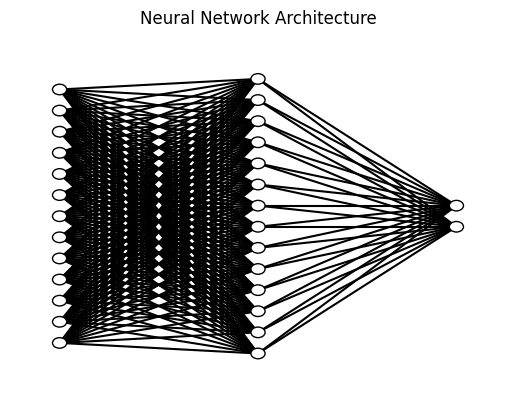

In [ ]:
fig = plt.figure()
ax = fig.gca()
ax.axis('off')
draw_neural_net(ax, .1, .9, .1, .9, [num_inputs, hidden_layer_neurons, num_outputs])
plt.title("Neural Network Architecture")
plt.show()

Epoch: 0, Error: 0.46672894541679016


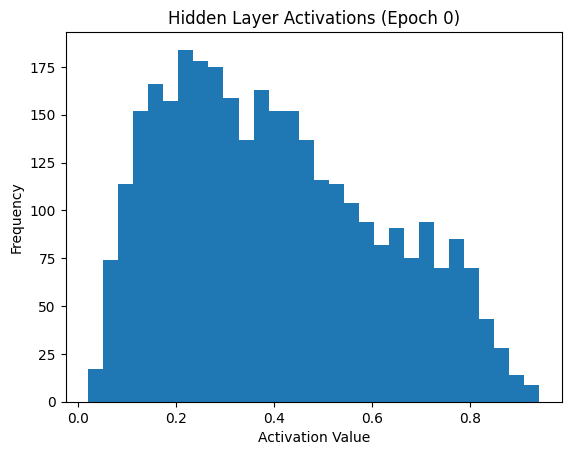

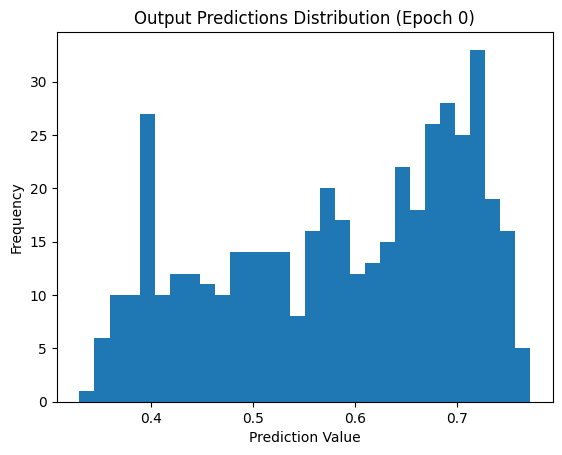

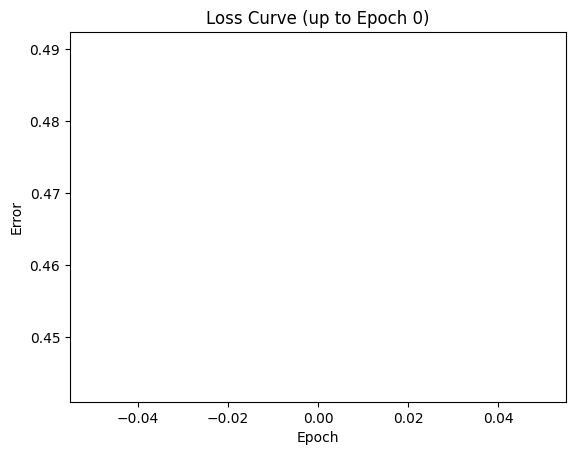

Epoch: 10000, Error: 0.011287099074228172


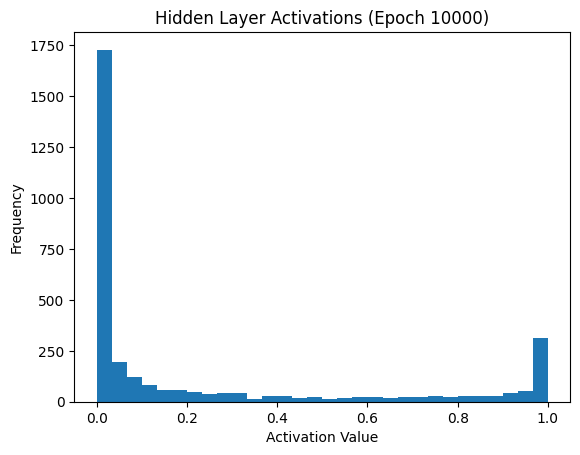

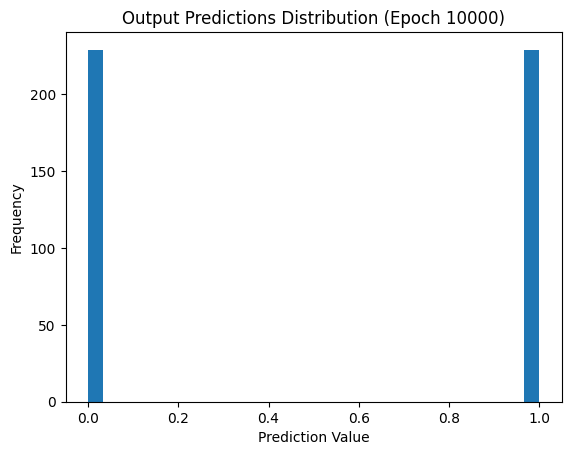

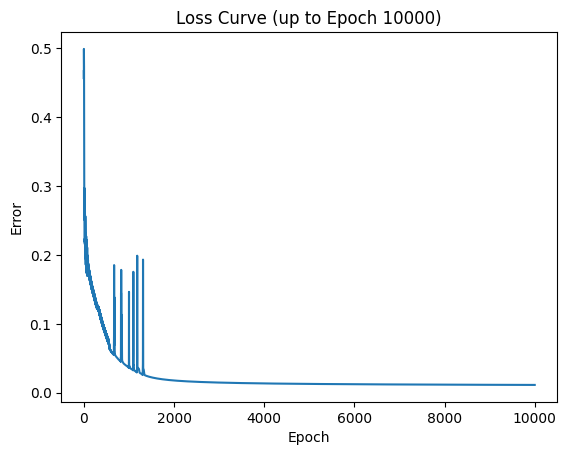

Epoch: 20000, Error: 0.010424101939708212


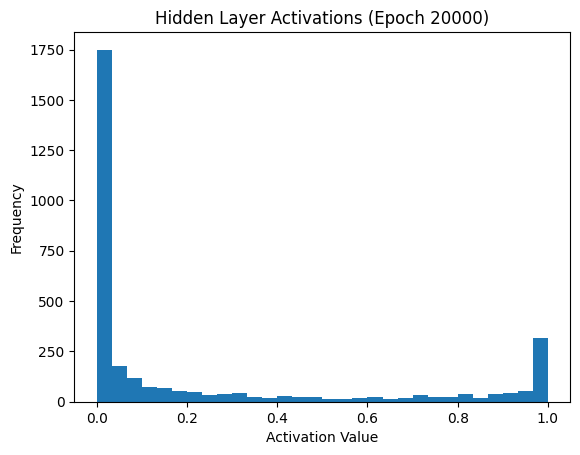

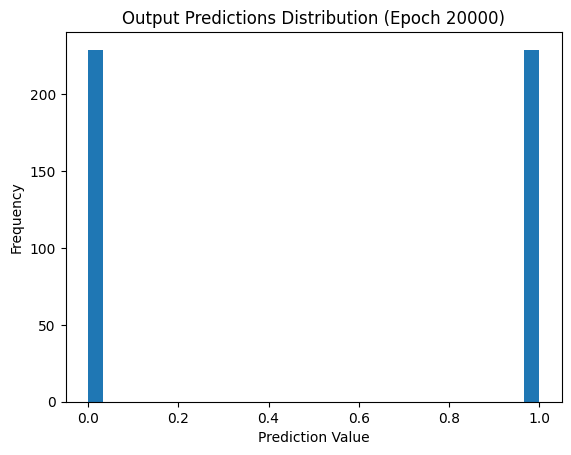

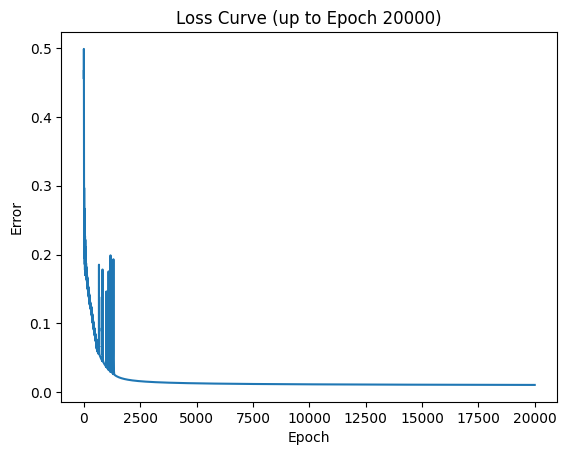

Epoch: 30000, Error: 0.010073901991087753


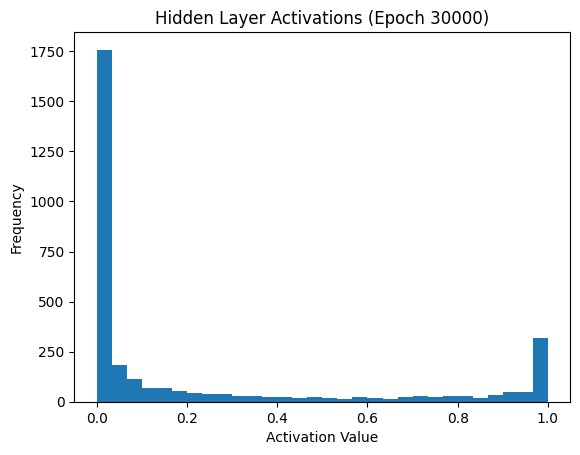

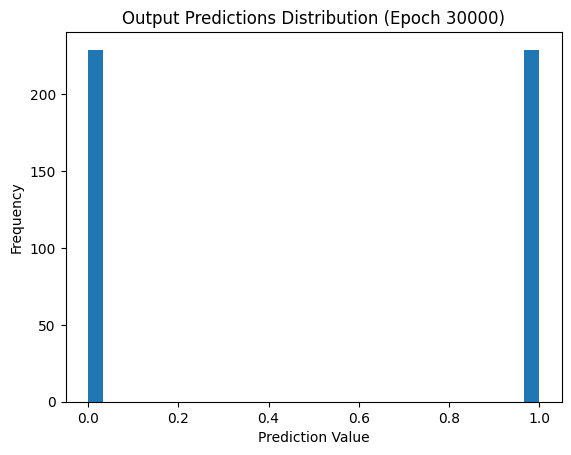

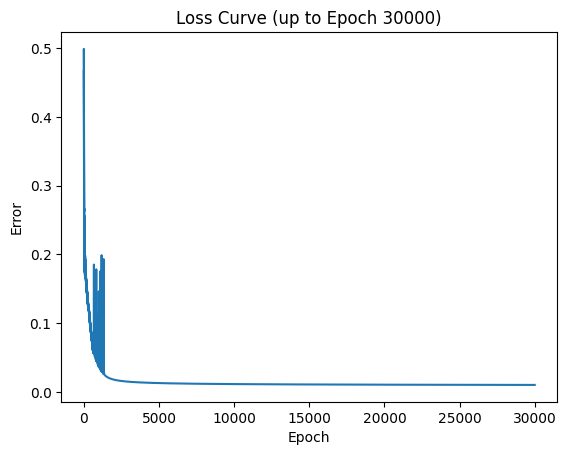

Epoch: 40000, Error: 0.009873629121568184


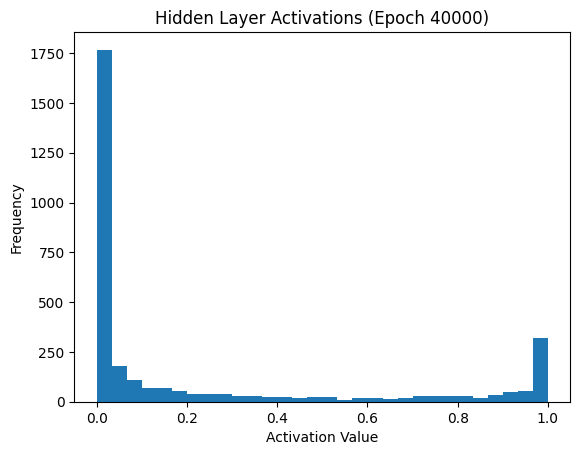

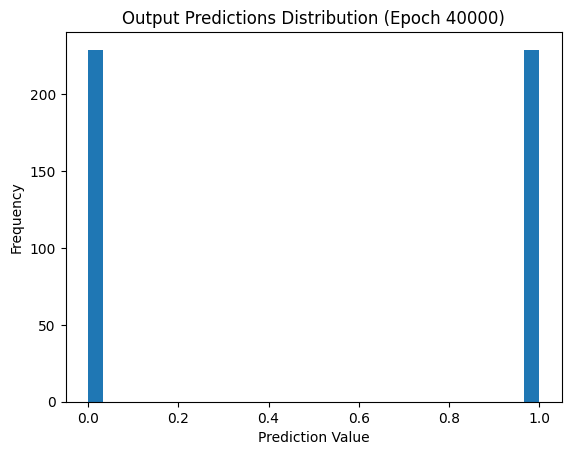

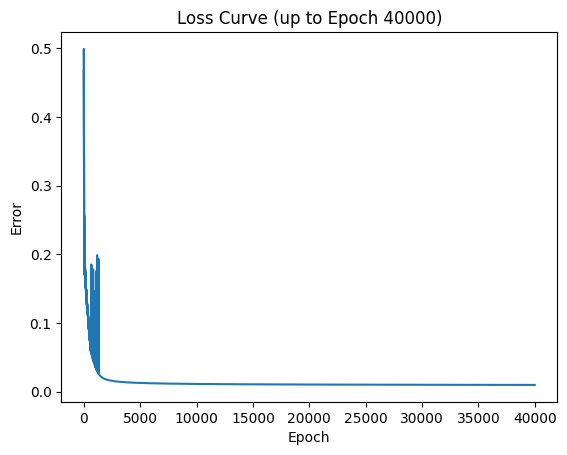

Error: 0.009740576468598645


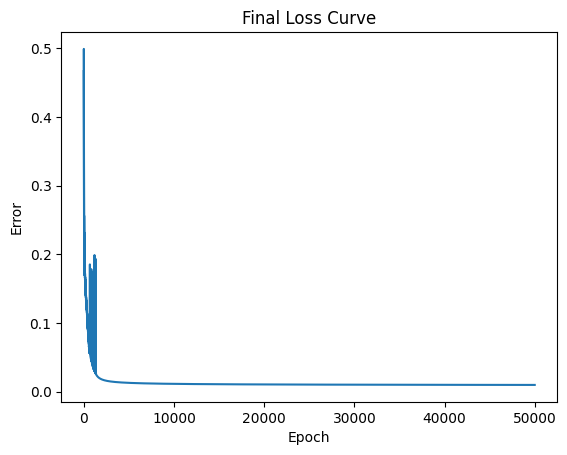

In [ ]:
learning_rate = 0.28 # slowly update the network
losses = []

for epoch in range(50000):
    l1 = 1/(1 + np.exp(-(np.dot(X, w1)))) # sigmoid function
    l2 = 1/(1 + np.exp(-(np.dot(l1, w2))))

    er = (abs(y - l2)).mean()
    losses.append(er)

    l2_delta = (y - l2)*(l2 * (1-l2))
    l1_delta = l2_delta.dot(w2.T) * (l1 * (1-l1))

    w2 += l1.T.dot(l2_delta) * learning_rate
    w1 += X.T.dot(l1_delta) * learning_rate

    # 🔹 Visualization checkpoints (every 10000 epochs)
    if epoch % 10000 == 0:
        print(f"Epoch: {epoch}, Error: {er}")

        # 1. Hidden layer activation distribution
        plt.figure()
        plt.hist(l1.flatten(), bins=30)
        plt.title(f"Hidden Layer Activations (Epoch {epoch})")
        plt.xlabel("Activation Value")
        plt.ylabel("Frequency")
        plt.show()

        # 2. Output prediction distribution
        plt.figure()
        plt.hist(l2.flatten(), bins=30)
        plt.title(f"Output Predictions Distribution (Epoch {epoch})")
        plt.xlabel("Prediction Value")
        plt.ylabel("Frequency")
        plt.show()

        # 3. Loss curve so far
        plt.figure()
        plt.plot(losses)
        plt.title(f"Loss Curve (up to Epoch {epoch})")
        plt.xlabel("Epoch")
        plt.ylabel("Error")
        plt.show()

print('Error:', er)


# 🔹 Final Loss Curve (clean view)
plt.figure()
plt.plot(losses)
plt.title("Final Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Error")
plt.show()

/tmp/ipykernel_255/2048197400.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y = np.array([targets[int(x)] for x in test.values[:,13:14]])


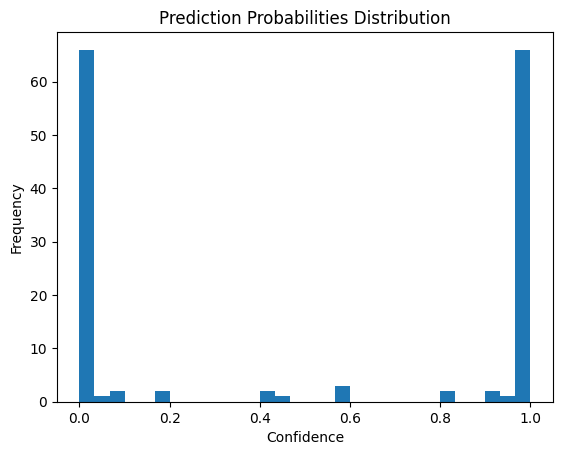

In [ ]:
#test the network for accuracy
X = test.values[:,:13]
y = np.array([targets[int(x)] for x in test.values[:,13:14]])

l1 = 1/(1 + np.exp(-(np.dot(X, w1))))
l2 = 1/(1 + np.exp(-(np.dot(l1, w2))))

np.round(l2,3)

plt.figure()
plt.hist(l2.flatten(), bins=30)
plt.title("Prediction Probabilities Distribution")
plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.show()

            target     Prediction
2          healthy        healthy
4          healthy        healthy
5          healthy  heart-disease
8          healthy        healthy
11         healthy        healthy
..             ...            ...
286  heart-disease        healthy
287  heart-disease        healthy
292  heart-disease  heart-disease
294  heart-disease  heart-disease
297  heart-disease  heart-disease

[74 rows x 2 columns]
Accuracy is :  57 / 74 : 77.02702702702703 %


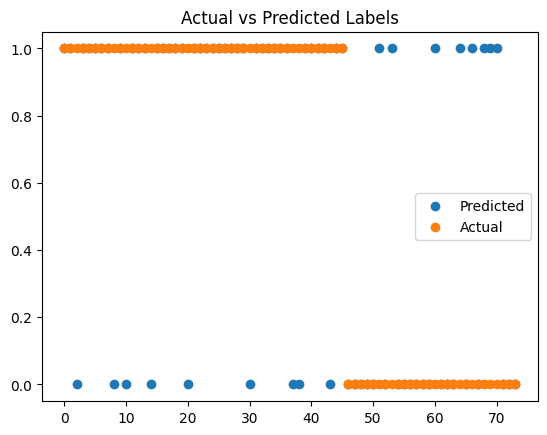

In [ ]:
#make the predictions
yp = np.argmax(l2, axis=1) # prediction
res = yp == np.argmax(y, axis=1)
correct = np.sum(res)/len(res)

testres = test[['target']].replace([0,1], ['heart-disease','healthy'])

testres['Prediction'] = yp
testres['Prediction'] = testres['Prediction'].replace([0,1], ['heart-disease','healthy',])

print(testres)
print('Accuracy is : ',sum(res),'/',len(res), ':', (correct*100),'%')

plt.figure()
plt.scatter(range(len(yp)), yp, label="Predicted")
plt.scatter(range(len(y)), np.argmax(y, axis=1), label="Actual")
plt.legend()
plt.title("Actual vs Predicted Labels")
plt.show()

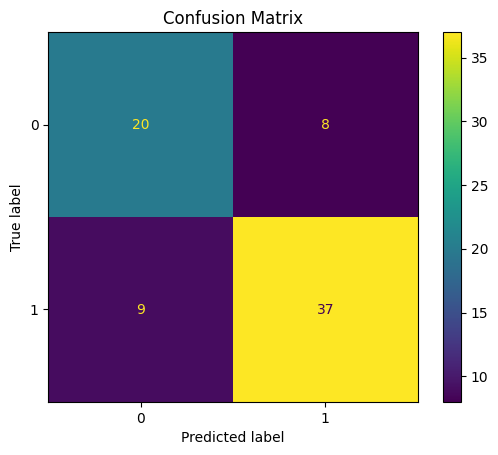

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(np.argmax(y, axis=1), yp)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()